# Evaluación Parcial N° 1: Fundamentos de Deep Learning
>Nombre: **Gabriel Hermosilla**
**Modelo de Clasificación: Fashion-MNIST**


## Carga y Preprocesamiento de Datos
Para este caso de estudio, se utilizó el set de datos **Fashion-MNIST**, el cual consta de 70.000 imágenes en escala de grises (28x28 píxeles) distribuidas en 10 categorías de prendas de vestir.

**Justificación del preprocesamiento:**
Las imágenes originales tienen valores de píxeles que van de 0 a 255. Para que la Red Neuronal (MLP) procese la información de manera más eficiente y el algoritmo de descenso de gradiente converja más rápido, normalizamos estos valores. Al dividir cada píxel por 255.0, escalamos los datos a un rango entre 0 y 1. Esto estabiliza numéricamente el modelo durante el entrenamiento.

In [2]:
# LIBRERÍAS
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np


In [3]:
# 1. Cargar el dataset
fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Nombres de las clases para visualizar más fácilmente después
class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [4]:
# 2. Preprocesamiento: Normalización
# Convertimos los valores de los píxeles (0-255) a punto flotante (0.0-1.0)
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Datos cargados y normalizados con éxito.")


Datos cargados y normalizados con éxito.


--- Exploración del Dataset ---
Forma de los datos de entrenamiento (x_train): (60000, 28, 28)
Cantidad de etiquetas de entrenamiento (y_train): 60000
Forma de los datos de prueba (x_test): (10000, 28, 28)
Valor máximo de un píxel post-normalización: 1.0


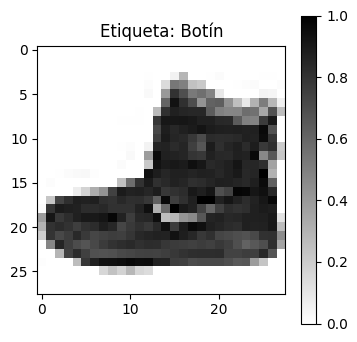

In [8]:
# Exploración de los tensores
print("--- Exploración del Dataset ---")
print(f"Forma de los datos de entrenamiento (x_train): {x_train.shape}")
print(f"Cantidad de etiquetas de entrenamiento (y_train): {len(y_train)}")
print(f"Forma de los datos de prueba (x_test): {x_test.shape}")
print(f"Valor máximo de un píxel post-normalización: {np.max(x_train[0])}") # Debe ser 1.0

# Demostración visual
plt.figure(figsize=(4,4))
# Tomamos la primera imagen del set de entrenamiento
plt.imshow(x_train[0], cmap=plt.cm.binary)
plt.colorbar()
plt.title(f"Etiqueta: {class_names[y_train[0]]}")
plt.grid(False)
plt.show()

## Definición del Modelo: Red Neuronal Multicapa (MLP)

Para resolver este problema de clasificación de imágenes, se implementó una arquitectura secuencial utilizando Keras.

**Arquitectura y Funciones:**
1.  **Capa de Entrada (Flatten):** Las imágenes son matrices de 28x28 píxeles. Esta capa "aplana" la matriz bidimensional en un vector unidimensional de 784 elementos ($28 \times 28 = 784$), preparándolos para ingresar a la red.
2.  **Capa Oculta y Función de Activación (ReLU):** Utilizamos una capa densa (fully connected) con 128 neuronas. La **función de activación** elegida es **ReLU** (Rectified Linear Unit). Su impacto es vital para la convergencia: introduce no linealidad al modelo permitiendo aprender patrones complejos, y evita el problema del "desvanecimiento del gradiente" que sufren otras funciones como la sigmoide, logrando que el modelo aprenda más rápido.
3.  **Capa de Salida y Función de Salida (Softmax):** La última capa tiene 10 neuronas, una por cada categoría de ropa. Usamos la **función de salida Softmax**, la cual transforma los valores brutos (logits) en probabilidades (valores entre 0 y 1 que suman 1). Esto nos permite identificar la clase más probable.
4.  **Función de Error (Loss):** Utilizaremos **Sparse Categorical Crossentropy**. Es la función matemática ideal cuando nuestras etiquetas son números enteros (0 al 9) en lugar de codificación *one-hot*. Esta función calcula la diferencia entre la distribución de probabilidad predicha y la real, guiando al algoritmo de *backpropagation* para ajustar los pesos.

In [9]:
# Definición de la arquitectura MLP
modelo_base = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28), name="Capa_Entrada_Aplanada"),
    tf.keras.layers.Dense(128, activation='relu', name="Capa_Oculta_1_ReLU"),
    tf.keras.layers.Dense(10, activation='softmax', name="Capa_Salida_Softmax")
])

# Compilación del modelo (definiendo función de error y métricas)
modelo_base.compile(
    optimizer='adam', # Optimizador que maneja el backpropagation y ajuste de pesos
    loss='sparse_categorical_crossentropy', # Función de error justificada
    metrics=['accuracy'] # Métrica para ir midiendo el desempeño inicial
)

print("Modelo MLP definido y compilado correctamente.")

Modelo MLP definido y compilado correctamente.


In [10]:
# Resumen de la arquitectura
print("--- Resumen de la Arquitectura del Modelo ---")
modelo_base.summary()

# Demostración del cálculo de parámetros para la capa oculta:
# 784 entradas * 128 neuronas + 128 sesgos (biases) = 100,480 parámetros

--- Resumen de la Arquitectura del Modelo ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Capa_Entrada_Aplanada (Flatten) │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Oculta_1_ReLU (Dense)      │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Salida_Softmax (Dense)     │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## Configuración, Optimización y Entrenamiento

Para entrenar nuestro modelo, debemos definir parámetros clave que controlarán cómo aprende la red neuronal. Además, implementaremos una técnica de optimización para mejorar su estabilidad.

**Justificación de Hiperparámetros y Optimización:**
*   **Técnica de Optimización (Dropout):** Para evitar el *overfitting* (sobreajuste, donde el modelo memoriza los datos en lugar de aprender patrones), agregaremos una capa de **Dropout** del 30% (0.3). Esto "apaga" aleatoriamente el 30% de las neuronas de la capa oculta en cada iteración de entrenamiento, forzando a la red a distribuir el aprendizaje y volverse más robusta y estable.
*   **Tasa de Aprendizaje (Learning Rate):** Configuraremos explícitamente el optimizador Adam con una tasa de `0.001`. Este valor controla el tamaño del "paso" que da el modelo al ajustar los pesos. Un valor de 0.001 es el estándar ideal: no tan grande como para saltarse el mínimo de error, ni tan pequeño como para que el entrenamiento sea eterno.
*   **Tamaño de Batch (Batch Size):** Usaremos `64`. Esto significa que la red actualizará sus pesos después de procesar 64 imágenes a la vez. Es un buen equilibrio: procesar de a 1 imagen es muy ruidoso y lento, y procesar las 60.000 de golpe consume demasiada memoria.
*   **Épocas (Epochs):** Entrenaremos por `15` épocas (veces que el modelo verá el set de datos completo). Usamos una fracción de los datos de entrenamiento (20%) como validación cruzada para monitorear en cada época si el modelo sigue mejorando o si empieza a sobreajustarse.

In [11]:
# 1. Definir un nuevo modelo incorporando la técnica de optimización: Dropout
modelo_optimizado = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28), name="Entrada"),
    tf.keras.layers.Dense(128, activation='relu', name="Capa_Oculta"),
    tf.keras.layers.Dropout(0.3, name="Optimizacion_Dropout"), # Apaga el 30% de las neuronas
    tf.keras.layers.Dense(10, activation='softmax', name="Salida")
])

# 2. Configurar los parámetros clave de entrenamiento
tasa_aprendizaje = 0.001
optimizador = tf.keras.optimizers.Adam(learning_rate=tasa_aprendizaje)

modelo_optimizado.compile(
    optimizer=optimizador,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Entrenamiento de la red
epocas = 15
tamano_batch = 64

print(f"Iniciando entrenamiento con LR={tasa_aprendizaje}, Batch={tamano_batch}, Épocas={epocas}...")

# Guardamos el historial del entrenamiento para graficarlo después
historial = modelo_optimizado.fit(
    x_train, y_train,
    epochs=epocas,
    batch_size=tamano_batch,
    validation_split=0.2, # Separa 20% de x_train para validar en cada época
    verbose=1 # Muestra la barra de progreso
)

print("Entrenamiento finalizado.")

Iniciando entrenamiento con LR=0.001, Batch=64, Épocas=15...
Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7872 - loss: 0.6074 - val_accuracy: 0.8468 - val_loss: 0.4306
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8439 - loss: 0.4355 - val_accuracy: 0.8449 - val_loss: 0.4127
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8574 - loss: 0.3956 - val_accuracy: 0.8673 - val_loss: 0.3625
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8651 - loss: 0.3725 - val_accuracy: 0.8695 - val_loss: 0.3553
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8693 - loss: 0.3597 - val_accuracy: 0.8733 - val_loss: 0.3519
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8749 - loss: 0.3424 - val_accuracy: 0.8744 - val_loss: 0.3465
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8777 - loss: 0.3326 - val_accuracy: 0.8757 - val_loss: 0.3383
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 

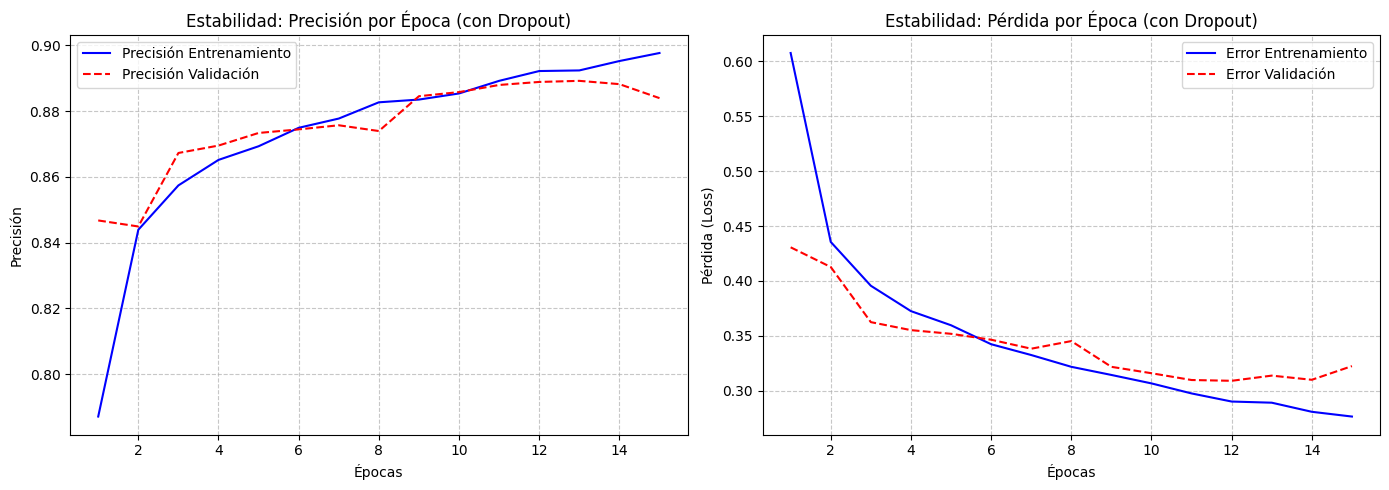

In [12]:
# 4. Demostración visual para la defensa: Gráficos de estabilidad
# Extraemos los datos del historial
acc = historial.history['accuracy']
val_acc = historial.history['val_accuracy']
loss = historial.history['loss']
val_loss = historial.history['val_loss']
epocas_rango = range(1, len(acc) + 1)

# Creamos la figura con dos subgráficos
plt.figure(figsize=(14, 5))

# Gráfico 1: Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epocas_rango, acc, 'b-', label='Precisión Entrenamiento')
plt.plot(epocas_rango, val_acc, 'r--', label='Precisión Validación')
plt.title('Estabilidad: Precisión por Época (con Dropout)')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Gráfico 2: Error (Loss)
plt.subplot(1, 2, 2)
plt.plot(epocas_rango, loss, 'b-', label='Error Entrenamiento')
plt.plot(epocas_rango, val_loss, 'r--', label='Error Validación')
plt.title('Estabilidad: Pérdida por Época (con Dropout)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (Loss)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Experimentos Controlados: Impacto de la Tasa de Aprendizaje

Para analizar el impacto de los hiperparámetros en el entrenamiento, realizaremos un experimento controlado variando **un solo parámetro a la vez** con respecto a nuestro modelo optimizado.

**Parámetro a variar:** Tasa de Aprendizaje (Learning Rate).
*   **Modelo Optimizado (Base):** Learning Rate = 0.001
*   **Modelo Experimental:** Learning Rate = 0.05

**Justificación del experimento:**
La tasa de aprendizaje define el tamaño del "paso" que da el optimizador para encontrar el mínimo error. Al aumentarla a 0.05, esperamos que el algoritmo dé pasos demasiado grandes, saltándose el punto óptimo (mínimo global). Esto debería reflejarse en un entrenamiento inestable, donde la precisión oscila violentamente y el error no logra disminuir de forma constante, demostrando empíricamente por qué un valor de 0.001 es mucho más adecuado para la convergencia de esta red.

In [13]:
# 1. Definimos un modelo con la misma arquitectura exacta
modelo_experimento = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation='softmax')
])

# 2. Variamos UN SOLO parámetro: Tasa de aprendizaje mucho más alta (0.05)
tasa_alta = 0.05
optimizador_exp = tf.keras.optimizers.Adam(learning_rate=tasa_alta)

modelo_experimento.compile(
    optimizer=optimizador_exp,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Iniciando experimento con LR={tasa_alta}...")

# 3. Entrenamos usando las mismas épocas y batch_size que el modelo anterior
historial_exp = modelo_experimento.fit(
    x_train, y_train,
    epochs=15, # Mismas épocas
    batch_size=64, # Mismo batch size
    validation_split=0.2,
    verbose=1
)

print("Experimento finalizado.")

Iniciando experimento con LR=0.05...
Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5668 - loss: 1.3261 - val_accuracy: 0.6838 - val_loss: 0.8840
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5425 - loss: 1.2328 - val_accuracy: 0.5415 - val_loss: 1.1138
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4265 - loss: 1.4819 - val_accuracy: 0.5199 - val_loss: 1.2121
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.4252 - loss: 1.4777 - val_accuracy: 0.5348 - val_loss: 1.1609
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4116 - loss: 1.5266 - val_accuracy: 0.5405 - val_loss: 1.1719
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4064 - loss: 1.5485 - val_accuracy: 0.5276 - val_loss: 1.2093
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4063 - loss: 1.5412 - val_accuracy: 0.5405 - val_loss: 1.1841
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.4

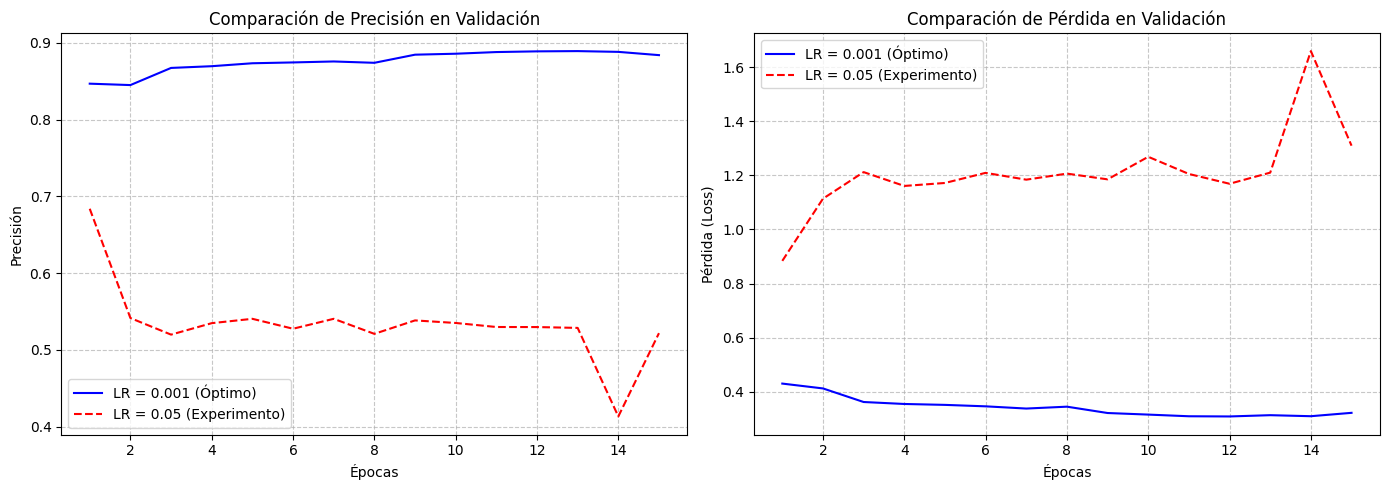

In [14]:
# Comparativa de Experimentos
# Extraemos la precisión de validación de ambos modelos
val_acc_optimo = historial.history['val_accuracy'] # Del modelo del Bloque 3
val_acc_exp = historial_exp.history['val_accuracy'] # Del modelo experimental

# Extraemos el error (loss) de validación de ambos modelos
val_loss_optimo = historial.history['val_loss']
val_loss_exp = historial_exp.history['val_loss']

epocas_rango = range(1, 16)

# Figura comparativa
plt.figure(figsize=(14, 5))

# Gráfico 1: Comparativa de Precisión
plt.subplot(1, 2, 1)
plt.plot(epocas_rango, val_acc_optimo, 'b-', label='LR = 0.001 (Óptimo)')
plt.plot(epocas_rango, val_acc_exp, 'r--', label='LR = 0.05 (Experimento)')
plt.title('Comparación de Precisión en Validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Gráfico 2: Comparativa de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(epocas_rango, val_loss_optimo, 'b-', label='LR = 0.001 (Óptimo)')
plt.plot(epocas_rango, val_loss_exp, 'r--', label='LR = 0.05 (Experimento)')
plt.title('Comparación de Pérdida en Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (Loss)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Evaluación del Modelo y Análisis de Métricas

Para evaluar el desempeño real de nuestro modelo optimizado, lo someteremos al conjunto de datos de prueba (`x_test`), el cual contiene 10.000 imágenes que la red neuronal nunca ha visto.

**Cálculo e Interpretación de Métricas:**
Para entender el rendimiento, no basta solo con la precisión general. Utilizaremos las siguientes métricas para cada categoría:
*   **Accuracy (Precisión Global):** El porcentaje total de predicciones correctas. Útil para una visión general.
*   **Precision (Precisión):** De todas las imágenes que el modelo *dijo* que eran una "Camisa", ¿cuántas lo eran realmente? Se calcula como: $Precision = \frac{Verdaderos Positivos}{Verdaderos Positivos + Falsos Positivos}$. Para mejorar este valor, podríamos ajustar el umbral de decisión o agregar penalizaciones a los falsos positivos.
*   **Recall (Sensibilidad):** De todas las "Camisas" *reales* que existen en los datos, ¿cuántas logró encontrar el modelo? Se calcula como: $Recall = \frac{Verdaderos Positivos}{Verdaderos Positivos + Falsos Negativos}$. Para mejorar el recall de una clase específica (como la categoría "Camisa", que suele confundirse con "Camiseta"), necesitaríamos recolectar más datos variados de esa clase o aplicar técnicas de aumento de datos (*data augmentation*).
*   **F1-Score:** Es la media armónica entre Precision y Recall. Es la métrica más confiable cuando hay desequilibrio en las clases o cuando queremos un balance perfecto entre no dar falsos positivos y no dejar pasar falsos negativos.

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns

# 1. Realizar predicciones con el modelo optimizado sobre los datos de prueba
print("Evaluando modelo en datos de prueba...")
y_pred_probabilidades = modelo_optimizado.predict(x_test)

# Convertir las probabilidades a la etiqueta de la clase ganadora (la de mayor probabilidad)
y_pred = np.argmax(y_pred_probabilidades, axis=1)

# 2. Generar el Cuadro Resumen de Métricas
reporte = classification_report(y_test, y_pred, target_names=class_names)
print("\n--- Cuadro Resumen de Métricas (Modelo Optimizado) ---")
print(reporte)

Evaluando modelo en datos de prueba...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- Cuadro Resumen de Métricas (Modelo Optimizado) ---
              precision    recall  f1-score   support

Camiseta/Top       0.84      0.82      0.83      1000
    Pantalón       0.99      0.97      0.98      1000
      Suéter       0.82      0.74      0.78      1000
     Vestido       0.88      0.89      0.89      1000
      Abrigo       0.73      0.88      0.80      1000
    Sandalia       0.96      0.97      0.97      1000
      Camisa       0.70      0.64      0.67      1000
   Zapatilla       0.96      0.90      0.93      1000
       Bolso       0.97      0.97      0.97      1000
       Botín       0.93      0.97      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [16]:
# 3. Evaluación final de ambas configuraciones en el set de prueba
loss_opt, acc_opt = modelo_optimizado.evaluate(x_test, y_test, verbose=0)
loss_exp, acc_exp = modelo_experimento.evaluate(x_test, y_test, verbose=0)

# 4. Crear tabla comparativa
datos_comparativos = {
    'Configuración': ['Óptimo (LR=0.001, Dropout=0.3)', 'Experimento (LR=0.05)'],
    'Accuracy Global (Prueba)': [f"{acc_opt:.4f}", f"{acc_exp:.4f}"],
    'Pérdida/Loss (Prueba)': [f"{loss_opt:.4f}", f"{loss_exp:.4f}"]
}
tabla_comparativa = pd.DataFrame(datos_comparativos)

print("\n--- Tabla Comparativa de Configuraciones ---")
display(tabla_comparativa)


--- Tabla Comparativa de Configuraciones ---


,Configuración,Accuracy Global (Prueba),Pérdida/Loss (Prueba)
0,"Óptimo (LR=0.001, Dropout=0.3)",0.8766,0.3468
1,Experimento (LR=0.05),0.5248,1.3178


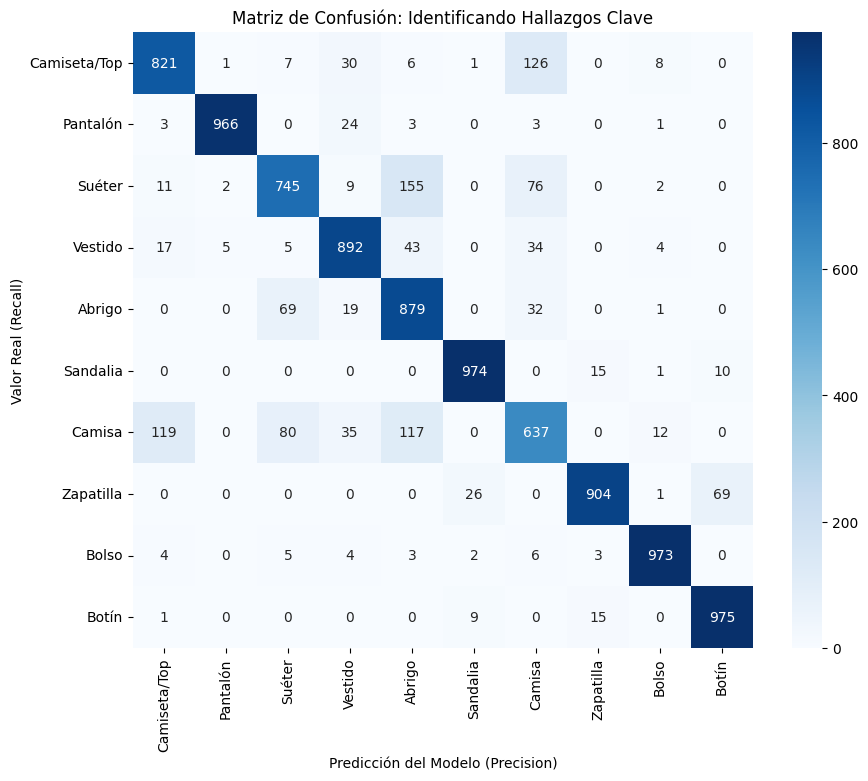

In [17]:
# 5. Demostración visual para la defensa: Matriz de Confusión
matriz = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción del Modelo (Precision)')
plt.ylabel('Valor Real (Recall)')
plt.title('Matriz de Confusión: Identificando Hallazgos Clave')
plt.show()